# One hidden unit as a finite-state controller

Analytical solve of a GRU that IS the fitted FSC, for a 2-state machine (`det_init`) and a
3-state machine (`ts`), at hidden sizes H = 1, 2, 3.

Every network here is the analytically **solved** GRU, not a network trained from scratch. The
only training in the notebook is in section 5, where the solved weights are used as the starting
point and nudged to ask whether that solution is stable.

## 0. Setup

In [1]:
# imports, the numpy GRU, the FSC loaders, and the analytical solver
import sys, os, glob, pickle
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn
from torch.func import jacrev
from scipy.optimize import least_squares

torch.set_default_dtype(torch.float64)

# pandas pickle compat shim, so the fitted FSC objects unpickle across versions
import pandas.core.arrays.string_ as _pd_str
from pandas.core.arrays._mixins import NDArrayBacked as _NDArrayBacked
def _compat_string_setstate(self, state):
    if isinstance(state, tuple) and len(state) == 2 and isinstance(state[1], np.ndarray):
        state = (state[0], state[1], {})
    return _NDArrayBacked.__setstate__(self, state)
_pd_str.StringArray.__setstate__ = _compat_string_setstate

REPO    = os.path.abspath(".")
FSC_SRC = os.path.abspath("FSC-inference-MAPSO/src")
if FSC_SRC not in sys.path:
    sys.path.insert(0, FSC_SRC)

# one GRU step in numpy, mirroring torch nn.GRU: h' = (1-z)*n + z*h
def _sigmoid(x):
    return np.where(x >= 0, 1.0 / (1.0 + np.exp(-np.abs(x))),
                    np.exp(-np.abs(x)) / (1.0 + np.exp(-np.abs(x))))
def _softmax(z):
    z = np.asarray(z, float); z = z - z.max(); e = np.exp(z); return e / e.sum()

def gru_step(h, x, P):
    H  = P["H"]
    gi = P["W_ih"] @ x + P["b_ih"]
    gh = P["W_hh"] @ h + P["b_hh"]
    r  = _sigmoid(gi[:H]    + gh[:H])
    z  = _sigmoid(gi[H:2*H] + gh[H:2*H])
    n  = np.tanh( gi[2*H:]  + r * gh[2*H:])
    return (1 - z) * n + z * h, {"reset": r, "update": z, "new": n}

def rnn_action_probs(h, P):
    return _softmax(np.atleast_1d(h) @ P["lin_W"].T + P["lin_b"])

def encode_input(a, y, A, Y):
    x = np.zeros(A + Y); x[a] = 1.0; x[A + y] = 1.0; return x

# teacher-forced hidden trajectory; h[t] is the state the readout uses to predict action t
def rnn_states(P, actions, observations, A, Y):
    h = np.zeros(P["H"]); out = [h.copy()]
    for t in range(len(actions)):
        h, _ = gru_step(h, encode_input(actions[t], observations[t], A, Y), P)
        out.append(h.copy())
    return np.array(out)

def load_dataset(path):
    raw = np.load(os.path.join(REPO, path))
    ra, ro = raw["actions"], raw["observations"]
    ActSpace = np.array(sorted(set(ra.flatten().tolist())))
    ObsSpace = np.array(sorted(set(ro.flatten().tolist())))
    a2i = {v: i for i, v in enumerate(ActSpace)}
    o2i = {v: i for i, v in enumerate(ObsSpace)}
    sessions = [{"actions":      np.array([a2i[a] for a in ra[i]], dtype=int),
                 "observations": np.array([o2i[o] for o in ro[i]], dtype=int)}
                for i in range(ra.shape[0])]
    win = int(np.where(ObsSpace == 1)[0][0]) if 1 in ObsSpace.tolist() else len(ObsSpace) - 1
    return dict(ActSpace=ActSpace, ObsSpace=ObsSpace, A=len(ActSpace), Y=len(ObsSpace),
                win_idx=win, lose_idx=1 - win, sessions=sessions)

# read the fitted FSC as a machine: policy pi(a|m), transitions g(m'|y,a,m), start rho, joint TMat
def load_fsc_machine(name):
    path = glob.glob(os.path.join(REPO, f"fitted_models/{name}/fsc/best_fsc_M*.pkl"))[0]
    with open(path, "rb") as f: fsc = pickle.load(f)
    fsc.set_mode("generation")
    return dict(fsc=fsc, M=int(fsc.M),
                pi=np.asarray(fsc.get_action_policy()),
                g=np.asarray(fsc.get_memory_transitions()),
                rho=np.asarray(fsc.get_rho()),
                TMat=np.asarray(fsc.get_TMat()))

# forward belief filter b_t(m) = P(memory = m | history up to t); b[0] = rho
def fsc_beliefs(TMat, rho, M, actions, observations):
    b = rho.copy(); out = [b.copy()]
    for t in range(len(actions)):
        bn = b @ TMat[int(observations[t]), :, :, int(actions[t])]
        s = bn.sum(); b = bn / s if s > 0 else np.ones(M) / M
        out.append(b.copy())
    return np.array(out)

# every (state, action, observation) the machine can be in; pairs the policy never takes are skipped
def machine_constraints(pi, g, rho, p_min=1e-6):
    M, A = pi.shape; Y = g.shape[0]
    trans = [(m, a, y, g[y, a, m]) for m in range(M) for a in range(A)
             if pi[m, a] > p_min for y in range(Y)]
    return trans, int(np.argmax(rho))

def _shapes(H, A, Y, M):
    return [("W_ih", (3*H, A+Y)), ("b_ih", (3*H,)), ("W_hh", (3*H, H)), ("b_hh", (3*H,)),
            ("lin_W", (A, H)), ("lin_b", (A,)), ("E", (H, M))]

def _unpack(theta, H, A, Y, M):
    out, i = {}, 0
    for k, sh in _shapes(H, A, Y, M):
        n = int(np.prod(sh)); out[k] = theta[i:i+n].reshape(sh); i += n
    return out

# the exact-solve residual (all requirements at the embedded states), reused by both solvers below
def _build_residual(pi, g, rho, H, conf=1e-3):
    M, A = pi.shape; Y = g.shape[0]
    trans, m0 = machine_constraints(pi, g, rho); K = len(trans)
    npar = sum(int(np.prod(sh)) for _, sh in _shapes(H, A, Y, M))
    m_idx = torch.tensor([t[0] for t in trans]); Xb = torch.zeros(K, A + Y)
    for i, (m, a, y, _) in enumerate(trans):
        Xb[i, a] = 1.0; Xb[i, A + y] = 1.0
    Gn      = torch.tensor(np.stack([t[3] for t in trans]))
    log_tgt = torch.tensor(np.log((1.0 - conf) * pi + conf / A))
    def residual_t(theta, lam_t):
        P = _unpack(theta, H, A, Y, M); E = P["E"]; Hb = E[:, m_idx].T
        gi = Xb @ P["W_ih"].T + P["b_ih"]; gh = Hb @ P["W_hh"].T + P["b_hh"]
        r  = torch.sigmoid(gi[:, :H]    + gh[:, :H])
        z  = torch.sigmoid(gi[:, H:2*H] + gh[:, H:2*H])
        n  = torch.tanh(   gi[:, 2*H:]  + r * gh[:, 2*H:])
        r_trans = ((1 - z) * n + z * Hb) - Gn @ E.T
        r_read  = torch.log_softmax(E.T @ P["lin_W"].T + P["lin_b"], 1) - log_tgt
        return torch.cat([r_trans.reshape(-1), r_read.reshape(-1), E[:, m0], lam_t * theta])
    jac_fn = jacrev(residual_t)
    def f(th, lv): return residual_t(torch.tensor(th), torch.tensor(lv)).numpy()
    def J(th, lv): return jac_fn(torch.tensor(th), torch.tensor(lv)).numpy()
    return f, J, npar, M, A, Y

def _unpack_sol(th, H, A, Y, M):
    P = {k: v.numpy().copy() for k, v in _unpack(torch.tensor(th), H, A, Y, M).items()}
    E = P.pop("E"); P["H"] = H
    return P, E

# solve for GRU weights and an embedding E so the GRU IS the machine (pi, g, rho); nothing baked in.
# among restarts, keeps the smallest-weight exact solution (the underdetermined solve's default choice).
def solve_gru_for_fsc(pi, g, rho, H, conf=1e-3, lam=3e-2, restarts=5, seed=0, exact_tol=1e-8):
    f, J, npar, M, A, Y = _build_residual(pi, g, rho, H, conf)
    kw = dict(jac=J, method="lm", xtol=1e-15, ftol=1e-15, gtol=1e-15, max_nfev=5000)
    best, rng = None, np.random.default_rng(seed)
    for k in range(restarts):
        th = 0.5 * rng.standard_normal(npar)
        th = least_squares(f, th, args=(lam,),   **kw).x
        th = least_squares(f, th, args=(1e-12,), **kw).x
        res = float(np.abs(f(th, 0.0)).max()); nrm = float(np.linalg.norm(th))
        key = (res > exact_tol, nrm)
        if best is None or key < best[0]:
            best = (key, res, th)
    _, res, th = best
    P, E = _unpack_sol(th, H, A, Y, M)
    return P, E, res

H_LIST = [1, 2, 3]
DSPEC  = [("det_init", "datasets/wsls_actions_observations_det_init.npz"),
          ("ts",       "datasets/ts_actions_observations.npz")]

DATA = {}
for name, file in DSPEC:
    D   = load_dataset(file)
    FSC = load_fsc_machine(name)
    A, Y = D["A"], D["Y"]
    DATA[name] = dict(name=name, D=D, A=A, Y=Y, WIN=D["win_idx"], LOSE=D["lose_idx"],
                      SESS=D["sessions"], FSC=FSC, M=FSC["M"], pi=FSC["pi"], g=FSC["g"],
                      rho=FSC["rho"], TMat=FSC["TMat"],
                      ACT_NAME={i: f"a={D['ActSpace'][i]:+d}" for i in range(A)},
                      OBS_NAME={D["win_idx"]: "win", D["lose_idx"]: "lose"})

print(f"{'dataset':>10}  {'sessions':>8}  {'trials':>6}  {'M':>3}  {'A':>3}  {'Y':>3}")
for name in DATA:
    d = DATA[name]
    print(f"{name:>10}  {len(d['SESS']):>8}  {len(d['SESS'][0]['actions']):>6}  "
          f"{d['M']:>3}  {d['A']:>3}  {d['Y']:>3}")


   dataset  sessions  trials    M    A    Y
  det_init      1000     200    2    2    2
        ts      1000     200    3    2    2


In [2]:
# plot style and the per-memory-state colours used throughout
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 120, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.22, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "legend.frameon": False,
})
C_STATE = {0: "#2a78d6", 1: "#eb6834", 2: "#1baf7a", 3: "#a35bd1"}
C_LR    = {0: "#111111", 1: "#2a78d6", 2: "#1baf7a", 3: "#eb6834", 4: "#a35bd1"}

## 1. The two controllers

/Users/nawaf/Library/Python/3.9/lib/python/site-packages/networkx/drawing/nx_pylab.py:437: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  node_collection = ax.scatter(


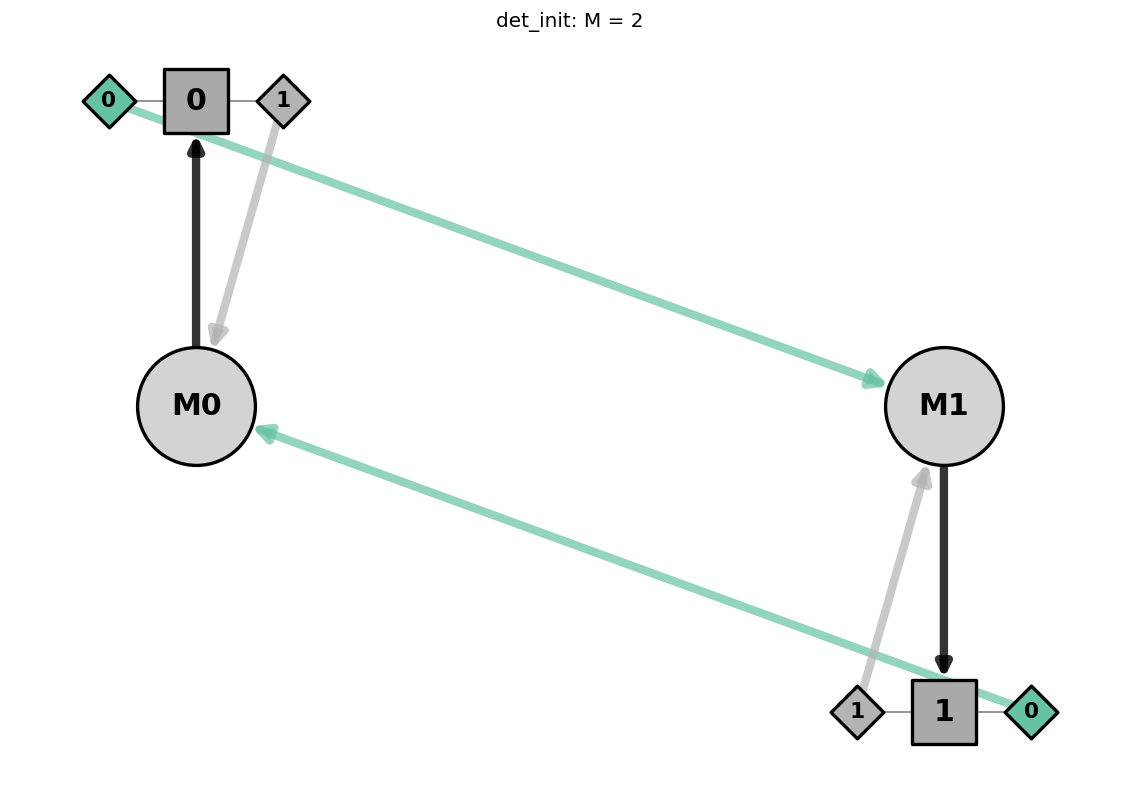

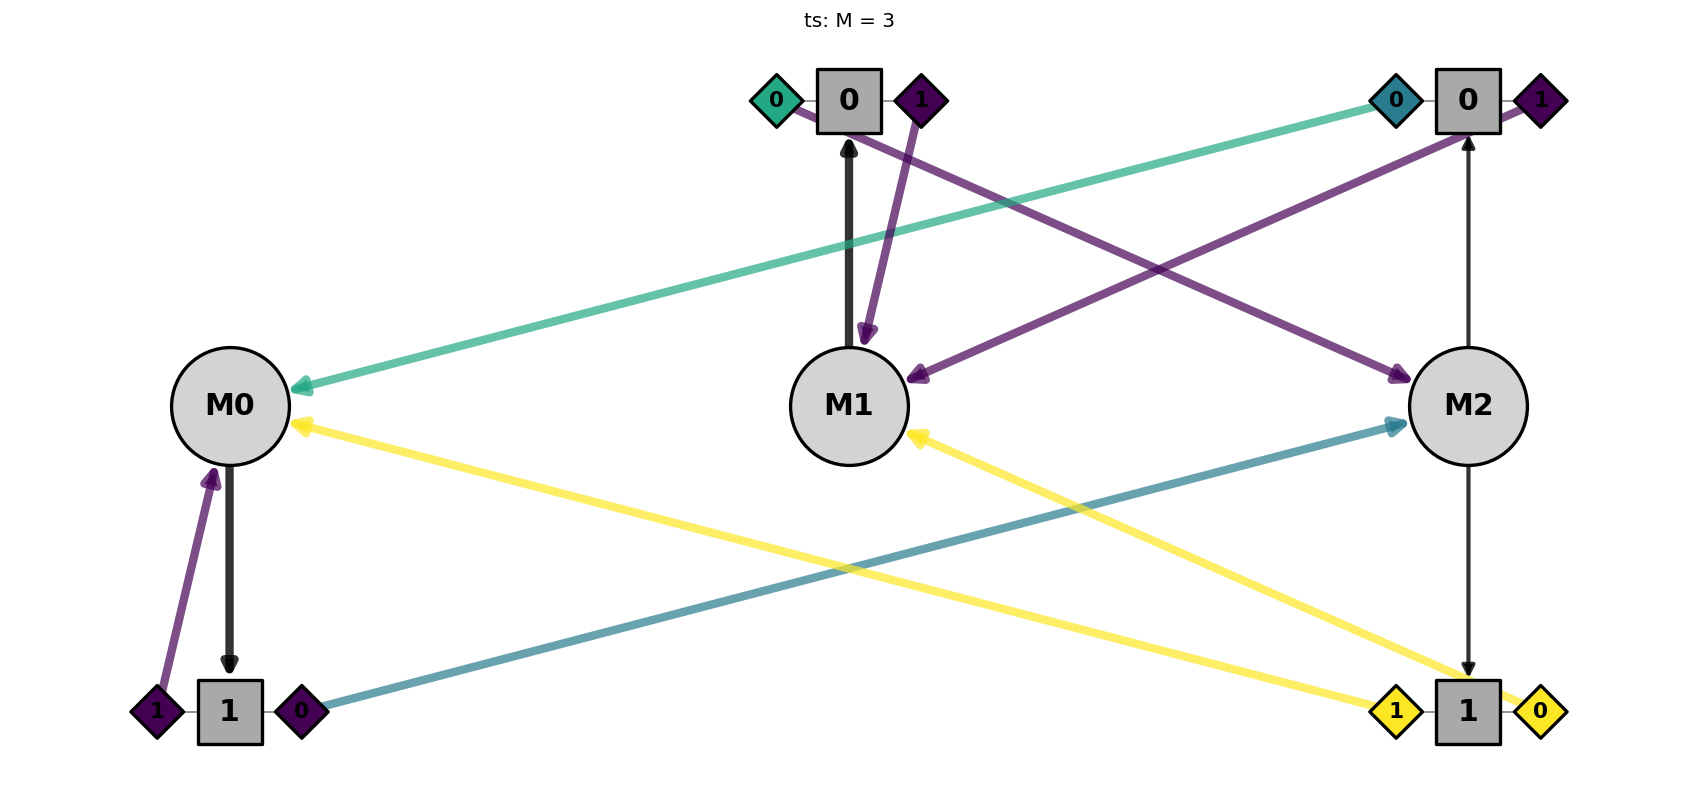

In [3]:
# the paper library's own FSC diagram, one per fitted machine
for name in DATA:
    d = DATA[name]
    obs_colors = plt.cm.Set2(np.linspace(0, 1, d["Y"]))
    d["FSC"]["fsc"].plot_FSC(observation_node_colors=obs_colors, th_action_probs=1e-3,
                             th_mem_transitions=1e-3, hide_unused_actions=True)
    plt.title(f"{name}: M = {d['M']}")
    plt.show()

In [4]:
# the machine parameters read straight off each fitted FSC
for name in DATA:
    d = DATA[name]; pi, g, rho = d["pi"], d["g"], d["rho"]
    A, Y, M = d["A"], d["Y"], d["M"]
    print(f"==== {name}   M={M}  A={A}  Y={Y} ====")
    print("pi(a|m):")
    for m in range(M):
        print("   m={}: {}".format(m, "  ".join(
            f"P({d['ACT_NAME'][a]})={pi[m,a]:.4f}" for a in range(A))))
    print(f"rho: {np.round(rho,4).tolist()}   start m={int(rho.argmax())}")
    print("g(m'|y,a,m):")
    for m in range(M):
        for a in range(A):
            if pi[m, a] > 1e-6:
                for y in range(Y):
                    print(f"   m={m} {d['ACT_NAME'][a]:<6} {d['OBS_NAME'][y]:<5} -> "
                          f"{np.round(g[y,a,m],4).tolist()}")
    print()

==== det_init   M=2  A=2  Y=2 ====
pi(a|m):
   m=0: P(a=-1)=1.0000  P(a=+1)=0.0000
   m=1: P(a=-1)=0.0000  P(a=+1)=1.0000
rho: [1.0, 0.0]   start m=0
g(m'|y,a,m):
   m=0 a=-1   lose  -> [0.0, 1.0]
   m=0 a=-1   win   -> [1.0, 0.0]
   m=1 a=+1   lose  -> [1.0, 0.0]
   m=1 a=+1   win   -> [0.0, 1.0]

==== ts   M=3  A=2  Y=2 ====
pi(a|m):
   m=0: P(a=-1)=0.0000  P(a=+1)=1.0000
   m=1: P(a=-1)=1.0000  P(a=+1)=0.0000
   m=2: P(a=-1)=0.4959  P(a=+1)=0.5041
rho: [0.0, 0.0, 1.0]   start m=2
g(m'|y,a,m):
   m=0 a=+1   lose  -> [0.0, 0.0, 1.0]
   m=0 a=+1   win   -> [1.0, 0.0, 0.0]
   m=1 a=-1   lose  -> [0.0, 0.0, 1.0]
   m=1 a=-1   win   -> [0.0, 1.0, 0.0]
   m=2 a=-1   lose  -> [1.0, 0.0, 0.0]
   m=2 a=-1   win   -> [0.0, 1.0, 0.0]
   m=2 a=+1   lose  -> [0.0, 1.0, 0.0]
   m=2 a=+1   win   -> [1.0, 0.0, 0.0]



## 2. Solving at H = 1, 2, 3

The solve is underdetermined: many weight sets are exact at the constraint points. The smallest-weight
one (the default) can be dynamically unstable and drift over data, so it fails to reproduce the policy
(section 3.4). The reference kept here is the smallest-weight exact solution that also reproduces the
policy over data (mean track error below tau) and is invertible where the dimension allows. Sections 3
onward then double-check the selected reference.

In [5]:
# mean distance of the hidden trajectory from the FSC belief manifold over data; small = reproduces policy
def track_err_quick(d, P, E, n=40):
    ds = []
    for s in d["SESS"][:n]:
        b = fsc_beliefs(d["TMat"], d["rho"], d["M"], s["actions"], s["observations"])
        h = rnn_states(P, s["actions"], s["observations"], d["A"], d["Y"])
        ds.append(np.linalg.norm(h - b @ E.T, axis=1))
    return float(np.concatenate(ds).mean())
def emb_rank(E, M): return int(np.linalg.matrix_rank(np.hstack([E.T, np.ones((M, 1))]), tol=1e-9))
def replay_res(d, P, E):
    trans, _ = machine_constraints(d["pi"], d["g"], d["rho"])
    return max(float(np.abs(gru_step(E[:, m], encode_input(a, y, d["A"], d["Y"]), P)[0] - E @ gn).max())
               for (m, a, y, gn) in trans)

# keep the smallest-weight exact solution that also reproduces the policy (track < tau); if the default
# already does, keep it; otherwise search varied-scale restarts and prefer invertible, then smallest weight.
def solve_stable(d, H, tau=1e-4):
    pi, g, rho, M, A, Y = d["pi"], d["g"], d["rho"], d["M"], d["A"], d["Y"]
    P0, E0, _ = solve_gru_for_fsc(pi, g, rho, H)
    if track_err_quick(d, P0, E0) < tau:
        return P0, E0
    f, J, npar, _, _, _ = _build_residual(pi, g, rho, H)
    kw = dict(jac=J, method="lm", xtol=1e-15, ftol=1e-15, gtol=1e-15, max_nfev=5000)
    found = []
    for sc in [0.5, 1, 2, 5, 15, 40, 100]:
        for sd in range(5):
            th = sc * np.random.default_rng(int(7919 * sc * 10) + sd).standard_normal(npar)
            th = least_squares(f, th, args=(3e-2,), **kw).x
            th = least_squares(f, th, args=(1e-12,), **kw).x
            if float(np.abs(f(th, 0.0)).max()) < 1e-8:
                P, E = _unpack_sol(th, H, A, Y, M)
                found.append((track_err_quick(d, P, E),
                              max(np.abs(v).max() for k, v in P.items() if k != "H"),
                              emb_rank(E, M), P, E))
    if not found:
        return P0, E0
    stable = [s for s in found if s[0] < tau]
    pool = stable if stable else found
    mr = max(s[2] for s in pool)
    _, _, _, P, E = min([s for s in pool if s[2] == mr], key=lambda s: s[1])
    return P, E

STABLE_CACHE = os.path.join(REPO, "fitted_models", "_stable_solve.pkl")
SOL = {name: {} for name in DATA}
if os.path.exists(STABLE_CACHE):
    _sc = pickle.load(open(STABLE_CACHE, "rb"))
else:
    _sc = {(name, H): solve_stable(DATA[name], H) for name in DATA for H in H_LIST}
    pickle.dump(_sc, open(STABLE_CACHE, "wb"))
for name in DATA:
    for H in H_LIST:
        P, E = _sc[(name, H)]
        SOL[name][H] = (P, E, replay_res(DATA[name], P, E))

print(f"{'dataset':>10}  {'H':>2}  {'max violation':>14}  {'max |weight|':>12}  {'track err':>10}  "
      f"{'rank':>4}  {'invertible':>10}")
for name in DATA:
    d = DATA[name]
    for H in H_LIST:
        P, E, res = SOL[name][H]
        mw = max(np.abs(v).max() for k, v in P.items() if k != "H")
        rk = emb_rank(E, d["M"])
        print(f"{name:>10}  {H:>2}  {res:>14.2e}  {mw:>12.1f}  {track_err_quick(d,P,E):>10.2e}  "
              f"{rk:>4}  {str(rk == d['M']):>10}")

   dataset   H   max violation  max |weight|   track err  rank  invertible


  det_init   1        7.99e-09          11.3    7.68e-09     2        True
  det_init   2        5.99e-10          11.8    1.04e-09     2        True


  det_init   3        6.05e-10          11.8    1.16e-09     2        True


        ts   1        1.07e-09        5689.3    1.17e-09     2       False


        ts   2        5.74e-09          22.7    1.23e-06     3        True


        ts   3        2.96e-16           5.4    3.38e-07     3        True


## 3. Verification over data

Two questions. First (3.1): does the solved network **produce the FSC's policy**, that is, do its
action probabilities match the data the FSC generated? Second (3.2): how exactly does it implement
the machine, step by step.

### 3.1 Does the solved network produce the policy?

In [6]:
# teacher-forced: feed the real (action, outcome) histories, read the model's action probabilities,
# and aggregate them into P(repeat action | previous action, previous outcome). Compare data, FSC, solved.
def transition_matrix_data(d, sessions):
    A, Y = d["A"], d["Y"]; num = np.zeros((A, Y, A)); den = np.zeros((A, Y))
    for s in sessions:
        a, o = s["actions"], s["observations"]
        for t in range(1, len(a)):
            num[a[t-1], o[t-1], a[t]] += 1; den[a[t-1], o[t-1]] += 1
    return num / np.maximum(den, 1)[:, :, None]

def transition_matrix_model(d, step_probs, sessions):
    A, Y = d["A"], d["Y"]; num = np.zeros((A, Y, A)); den = np.zeros((A, Y))
    for s in sessions:
        a, o = s["actions"], s["observations"]; p = step_probs(s)
        for t in range(1, len(a)):
            num[a[t-1], o[t-1]] += p[t]; den[a[t-1], o[t-1]] += 1
    return num / np.maximum(den, 1)[:, :, None]

def rates_from_matrix(d, T):
    A, WIN, LOSE = d["A"], d["WIN"], d["LOSE"]
    return (float(np.mean([T[a, WIN, a] for a in range(A)])),
            float(np.mean([1 - T[a, LOSE, a] for a in range(A)])))

def probs_fsc(d):
    return lambda s: fsc_beliefs(d["TMat"], d["rho"], d["M"],
                                 s["actions"], s["observations"])[:-1] @ d["pi"]
def probs_rnn(d, P):
    return lambda s: np.array([rnn_action_probs(hv, P)
                     for hv in rnn_states(P, s["actions"], s["observations"], d["A"], d["Y"])[:-1]])

EVAL_N = 200
for name in DATA:
    d = DATA[name]; ev = d["SESS"][:EVAL_N]
    Td = transition_matrix_data(d, ev)
    models = [("data", None), ("FSC", probs_fsc(d))]
    models += [(f"solved H={H}", probs_rnn(d, SOL[name][H][0])) for H in H_LIST]
    print(f"==== {name} ====")
    print(f"{'model':>12}  {'P(stay|win)':>11}  {'P(shift|lose)':>13}  {'max dev from data':>17}")
    for tag, sp in models:
        T = Td if sp is None else transition_matrix_model(d, sp, ev)
        sw, sl = rates_from_matrix(d, T)
        dev = "" if sp is None else f"{max(abs(T[a,y,a]-Td[a,y,a]) for a in range(d['A']) for y in range(d['Y'])):.4f}"
        print(f"{tag:>12}  {sw:>11.4f}  {sl:>13.4f}  {dev:>17}")
    print()

==== det_init ====
       model  P(stay|win)  P(shift|lose)  max dev from data
        data       1.0000         1.0000                   
         FSC       1.0000         1.0000             0.0000


  solved H=1       0.9995         0.9995             0.0005


  solved H=2       0.9995         0.9995             0.0005


  solved H=3       0.9995         0.9995             0.0005

==== ts ====
       model  P(stay|win)  P(shift|lose)  max dev from data
        data       1.0000         0.6686                   
         FSC       1.0000         0.6691             0.0037


  solved H=1       0.9995         0.6689             0.0036


  solved H=2       0.9995         0.6689             0.0036


  solved H=3       0.9995         0.6689             0.0036



### 3.2 How exactly it implements the machine

In [7]:
# replay err = one-step transition error at the embedded states; track err = mean distance of the
# hidden state from the FSC belief embedding E@b over real data; CE = predictive cross-entropy per trial.
def ce_fsc(d, sessions):
    tot = n = 0.0
    for s in sessions:
        b = fsc_beliefs(d["TMat"], d["rho"], d["M"], s["actions"], s["observations"])[:-1] @ d["pi"]
        b = np.clip(b, 1e-12, 1.0)
        tot += -np.log(b[np.arange(len(s["actions"])), s["actions"]]).sum(); n += len(s["actions"])
    return tot / n

def ce_rnn(d, P, sessions):
    tot = n = 0.0
    for s in sessions:
        h = rnn_states(P, s["actions"], s["observations"], d["A"], d["Y"])[:-1]
        pr = np.clip(np.array([rnn_action_probs(hv, P) for hv in h]), 1e-12, 1.0)
        tot += -np.log(pr[np.arange(len(s["actions"])), s["actions"]]).sum(); n += len(s["actions"])
    return tot / n

def replay_error(d, P, E):
    trans, _ = machine_constraints(d["pi"], d["g"], d["rho"])
    return max(np.abs(gru_step(E[:, m], encode_input(a, y, d["A"], d["Y"]), P)[0] - E @ gn).max()
               for (m, a, y, gn) in trans)

def track_error(d, P, E, sessions):
    ds = []
    for s in sessions:
        b = fsc_beliefs(d["TMat"], d["rho"], d["M"], s["actions"], s["observations"])
        h = rnn_states(P, s["actions"], s["observations"], d["A"], d["Y"])
        ds.append(np.linalg.norm(h - b @ E.T, axis=1))
    return float(np.concatenate(ds).mean())

for name in DATA:
    DATA[name]["ce_fsc"] = ce_fsc(DATA[name], DATA[name]["SESS"][:EVAL_N])

print(f"{'dataset':>10}  {'H':>2}  {'replay err':>10}  {'track err':>10}  "
      f"{'CE solved':>10}  {'CE FSC':>9}")
for name in DATA:
    d = DATA[name]; ev = d["SESS"][:EVAL_N]
    for H in H_LIST:
        P, E, res = SOL[name][H]
        print(f"{name:>10}  {H:>2}  {replay_error(d,P,E):>10.2e}  {track_error(d,P,E,ev):>10.2e}  "
              f"{ce_rnn(d,P,ev):>10.4f}  {d['ce_fsc']:>9.4f}")

   dataset   H  replay err   track err   CE solved     CE FSC


  det_init   1    7.99e-09    7.89e-09      0.0005     0.0000


  det_init   2    5.99e-10    1.02e-09      0.0005     0.0000


  det_init   3    6.05e-10    1.14e-09      0.0005     0.0000


        ts   1    1.07e-09    1.16e-09      0.1890     0.1887


        ts   2    5.74e-09    1.23e-06      0.1890     0.1887


        ts   3    2.96e-16    3.23e-07      0.1890     0.1887


In [8]:
# is track error sensitive to how the FSC states are numbered? relabel (flip states 1 and 2) and recompute
def track_relabel(d, P, E, sessions, perm, apply_to_E):
    Ep = E[:, perm] if apply_to_E else E
    ds = []
    for s in sessions:
        b = fsc_beliefs(d["TMat"], d["rho"], d["M"], s["actions"], s["observations"])[:, perm]
        h = rnn_states(P, s["actions"], s["observations"], d["A"], d["Y"])
        ds.append(np.linalg.norm(h - b @ Ep.T, axis=1))
    return float(np.concatenate(ds).mean())

print(f"{'dataset':>10}  {'H':>2}  {'track (as is)':>13}  {'flip 1<->2 (E & belief)':>24}  {'flip belief only':>18}")
for name, H in [("det_init", 1), ("ts", 2)]:
    d = DATA[name]; P, E, _ = SOL[name][H]; ev = d["SESS"][:EVAL_N]; M = d["M"]
    perm = np.arange(M); perm[0], perm[1] = 1, 0
    print(f"{name:>10}  {H:>2}  {track_error(d,P,E,ev):>13.2e}  "
          f"{track_relabel(d,P,E,ev,perm,True):>24.2e}  {track_relabel(d,P,E,ev,perm,False):>18.2e}")

   dataset   H  track (as is)   flip 1<->2 (E & belief)    flip belief only


  det_init   1       7.89e-09                  7.89e-09            7.86e-01


        ts   2       1.23e-06                  1.23e-06            9.32e-01


Track error is unchanged by a consistent relabel of the FSC states (flip states 1 and 2 in both the
embedding and the belief and the number is identical) and moves only under an inconsistent one (flip the
belief while leaving the embedding, which is a bookkeeping error, not a valid relabel). So the metric does
not depend on how the states are numbered; it measures whether the hidden state sits at the embedding of
the FSC's current belief. That is the right check for the solved networks here, which sit exactly at their
own embedding. It is not used to judge the retraining sweep in section 5.1: a network being retrained slides
its representation to an equivalent embedding, so distance from the original one grows even while behaviour
stays perfect.

### 3.3 Off the data manifold: does the rule still hold?

Prime each solved net where it just won on an arm, then feed nothing but wins on that arm, past the
longest win streak the data ever contained. Win-stay says the only correct curve is flat: keep
playing the winning arm. Holding flat out there, where no training data lives, is the evidence that
the network implements the rule rather than fitting the outputs.

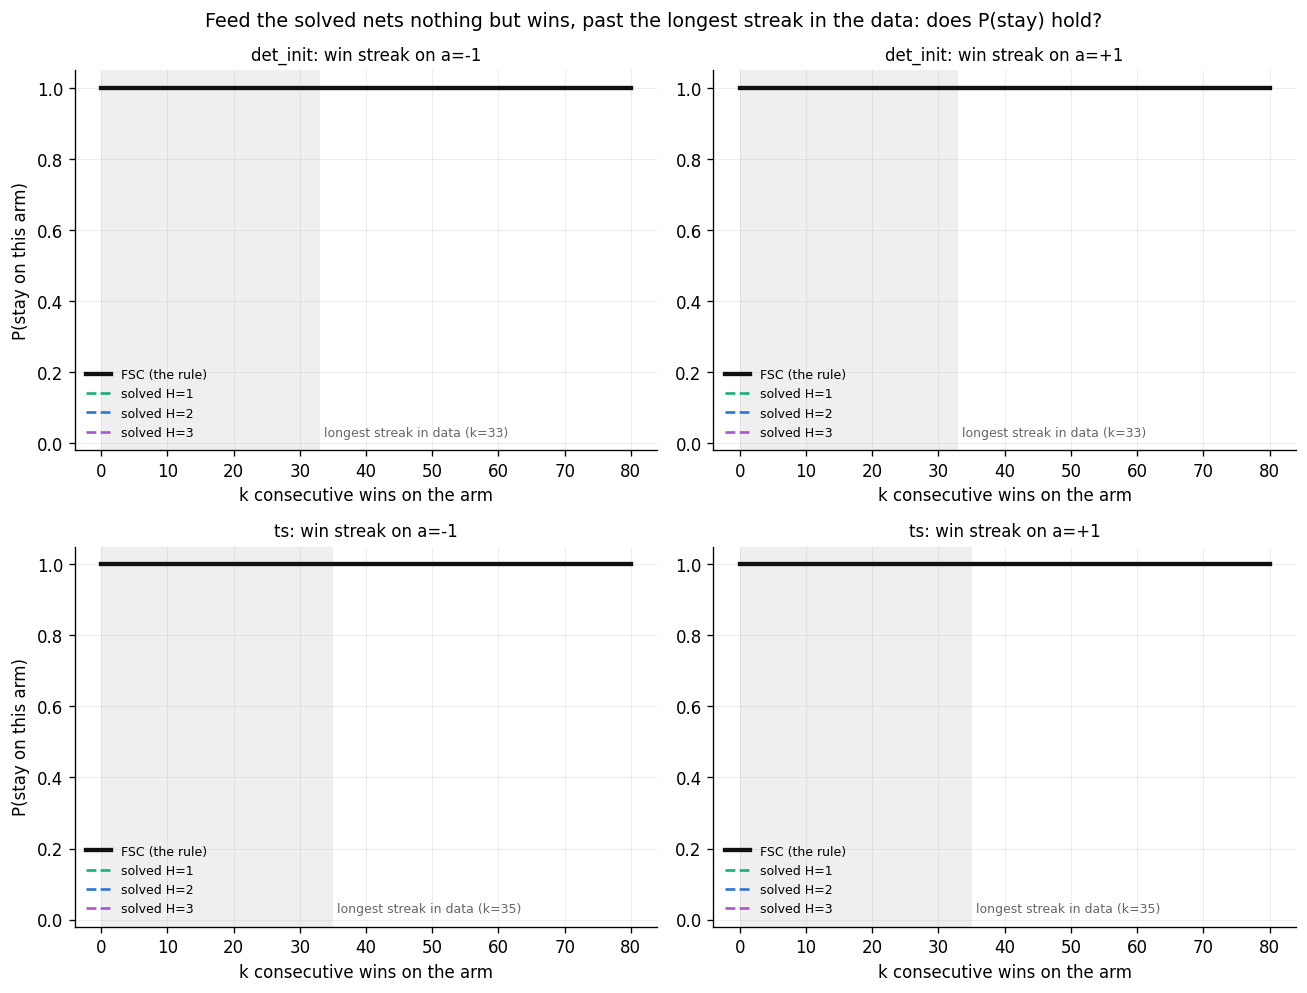

   dataset     arm   H  drift (max ptp)  max dev from FSC
  det_init    a=-1   1         6.18e-09          5.00e-04
  det_init    a=-1   2         1.04e-14          5.00e-04
  det_init    a=-1   3         3.77e-15          5.00e-04
  det_init    a=+1   1         1.08e-10          5.00e-04
  det_init    a=+1   2         3.81e-10          5.00e-04
  det_init    a=+1   3         3.90e-10          5.00e-04
        ts    a=-1   1         0.00e+00          5.00e-04
        ts    a=-1   2         2.44e-11          5.00e-04
        ts    a=-1   3         9.17e-11          5.00e-04
        ts    a=+1   1         0.00e+00          5.00e-04
        ts    a=+1   2         9.75e-12          5.00e-04
        ts    a=+1   3         5.48e-14          5.00e-04


In [9]:
# win-streak probe: prime at the win-state, feed straight wins past the longest streak, track P(stay)
KMAX = 80
C_H = {1: "#1baf7a", 2: "#2a78d6", 3: "#a35bd1"}

def win_state(d, a0): return int(np.argmax(d["pi"][:, a0]))
def win_h(d, P, a0, n=80):
    hs = []
    for s in d["SESS"][:n]:
        h = np.zeros(P["H"])
        for t in range(len(s["actions"])):
            h, _ = gru_step(h, encode_input(s["actions"][t], s["observations"][t], d["A"], d["Y"]), P)
            if s["actions"][t] == a0 and s["observations"][t] == d["WIN"]: hs.append(h.copy())
    return np.median(np.stack(hs), 0) if hs else np.zeros(P["H"])
def rnn_probe(d, P, a0, kmax=KMAX):
    h = np.asarray(win_h(d, P, a0), float); x = encode_input(a0, d["WIN"], d["A"], d["Y"])
    out = [rnn_action_probs(h, P)[a0]]
    for _ in range(kmax): h, _ = gru_step(h, x, P); out.append(rnn_action_probs(h, P)[a0])
    return np.array(out)
def fsc_probe(d, a0, kmax=KMAX):
    b = np.zeros(d["M"]); b[win_state(d, a0)] = 1.0; out = [float((b @ d["pi"])[a0])]
    for _ in range(kmax):
        bn = b @ d["TMat"][d["WIN"], :, :, a0]; s = bn.sum(); b = bn / s if s > 0 else b
        out.append(float((b @ d["pi"])[a0]))
    return np.array(out)
def max_streak(d):
    m = 0
    for s in d["SESS"]:
        r = 0
        for o in s["observations"]: r = r + 1 if o == d["WIN"] else 0; m = max(m, r)
    return m

kk = np.arange(KMAX + 1)
fig, axes = plt.subplots(len(DATA), 2, figsize=(11.0, 4.2 * len(DATA)), squeeze=False)
DRIFT = {}
for row, name in enumerate(DATA):
    d = DATA[name]; ms = max_streak(d)
    for a0 in range(d["A"]):
        ax = axes[row, a0]
        ax.axvspan(0, ms, color="#8a8a86", alpha=0.13, lw=0)
        ax.text(ms, 0.03, f" longest streak in data (k={ms})", fontsize=7.5, color="0.4",
                ha="left", va="bottom", transform=ax.get_xaxis_transform())
        fp = fsc_probe(d, a0)
        ax.plot(kk, fp, color="#111111", lw=2.6, label="FSC (the rule)", zorder=5)
        for H in H_LIST:
            rp = rnn_probe(d, SOL[name][H][0], a0)
            DRIFT[(name, a0, H)] = (float(np.ptp(rp)), float(np.abs(rp - fp).max()))
            ax.plot(kk, rp, color=C_H[H], lw=1.6, ls="--", label=f"solved H={H}")
        ax.set_ylim(-0.02, 1.05); ax.set_title(f"{name}: win streak on {d['ACT_NAME'][a0]}", fontsize=10)
        ax.set_xlabel("k consecutive wins on the arm")
        if a0 == 0: ax.set_ylabel("P(stay on this arm)")
        ax.legend(fontsize=7.5, loc="lower left")
fig.suptitle("Feed the solved nets nothing but wins, past the longest streak in the data: does P(stay) hold?",
             fontsize=11.5)
plt.tight_layout(); plt.show()

print(f"{'dataset':>10}  {'arm':>6}  {'H':>2}  {'drift (max ptp)':>15}  {'max dev from FSC':>16}")
for name in DATA:
    for a0 in range(DATA[name]["A"]):
        for H in H_LIST:
            dr, dv = DRIFT[(name, a0, H)]
            print(f"{name:>10}  {DATA[name]['ACT_NAME'][a0]:>6}  {H:>2}  {dr:>15.2e}  {dv:>16.2e}")

Every solved net stays on the FSC's line to within about 1e-8 across 80 straight wins, roughly
45 past the longest streak the data contained. A network that had only fit the outputs would have no
reason to hold out there and would peel off the rule as k leaves the shaded region; these do not.
The probe holds all sizes flat, so it does not separate H = 1 from the larger ones here: a pure win
streak sits in a stable win-state for every size, and the drift that separates them shows up only on
the full trajectories of section 3.2, which pass through losses and the stochastic state.

### 3.4 The selection: why not the smallest-weight solve

In [10]:
# the smallest-weight exact solve (the default) is exact at the constraint points but can be dynamically
# unstable. drift is a trajectory property: perturb the hidden state mid-session and measure how the
# dynamics amplify it along the real path (a single fixed-point eigenvalue does not predict it).
_rng = np.random.default_rng(0)
def perturb_growth(d, P, t0=100, eps=1e-8, n=40):
    A, Y = d["A"], d["Y"]; worst = 0.0
    for s in d["SESS"][:n]:
        acts, obs = s["actions"], s["observations"]; T = len(acts)
        h = np.zeros(P["H"])
        for t in range(t0): h, _ = gru_step(h, encode_input(acts[t], obs[t], A, Y), P)
        v = _rng.standard_normal(P["H"]); hp = h + eps * v / np.linalg.norm(v); hb = h.copy()
        for t in range(t0, T):
            x = encode_input(acts[t], obs[t], A, Y)
            hb, _ = gru_step(hb, x, P); hp, _ = gru_step(hp, x, P)
        worst = max(worst, float(np.linalg.norm(hp - hb) / eps))
    return worst

# the default smallest-weight solve for the two sizes the selection had to repair
DEFAULT = {("ts", H): solve_gru_for_fsc(DATA["ts"]["pi"], DATA["ts"]["g"], DATA["ts"]["rho"], H)[:2]
           for H in [2, 3]}
d = DATA["ts"]; ev = d["SESS"][:60]
print(f"ts:  the smallest-weight default vs the selected reference\n")
print(f"{'H':>2}  {'solution':>26}  {'max|weight|':>11}  {'track err':>10}  {'perturb growth':>15}")
for H in [2, 3]:
    for tag, (P, E) in [("default (smallest weight)", DEFAULT[("ts", H)]),
                        ("selected reference", (SOL["ts"][H][0], SOL["ts"][H][1]))]:
        mw = max(np.abs(v).max() for k, v in P.items() if k != "H")
        print(f"{H:>2}  {tag:>26}  {mw:>11.1f}  {track_error(d,P,E,ev):>10.1e}  {perturb_growth(d,P):>15.1e}")

ts:  the smallest-weight default vs the selected reference

 H                    solution  max|weight|   track err   perturb growth
 2   default (smallest weight)          6.2     3.2e-01          5.2e+03


 2          selected reference         22.7     1.2e-06          2.2e-04
 3   default (smallest weight)          7.0     3.2e-01          1.1e+04


 3          selected reference          5.4     3.3e-07          0.0e+00


In [11]:
# same policy test as 3.1, ts H=2 and H=3: the smallest-weight default vs the selected reference
d = DATA["ts"]; ev = d["SESS"][:EVAL_N]; Td = transition_matrix_data(d, ev)
print(f"{'H':>2}  {'solution':>26}  {'P(stay|win)':>11}  {'P(shift|lose)':>13}  {'CE/trial':>9}")
sw, sl = rates_from_matrix(d, Td)
print(f"{'':>2}  {'data':>26}  {sw:>11.4f}  {sl:>13.4f}  {'--':>9}")
for H in [2, 3]:
    for tag, P in [("default (smallest weight)", DEFAULT[("ts", H)][0]),
                   ("selected reference", SOL["ts"][H][0])]:
        T = transition_matrix_model(d, probs_rnn(d, P), ev); sw, sl = rates_from_matrix(d, T)
        print(f"{H:>2}  {tag:>26}  {sw:>11.4f}  {sl:>13.4f}  {ce_rnn(d,P,ev):>9.4f}")

 H                    solution  P(stay|win)  P(shift|lose)   CE/trial
                          data       1.0000         0.6686         --


 2   default (smallest weight)       0.8441         0.6507     2.2370


 2          selected reference       0.9995         0.6689     0.1890


 3   default (smallest weight)       0.8438         0.6510     2.1794


 3          selected reference       0.9995         0.6689     0.1890


The smallest-weight default is not a solve failure: at H = 2 and H = 3 it is exact at the constraint
points to 1e-16. What it lacks is dynamical stability. Perturb the hidden state mid-session and follow the
real trajectory: a reference that reproduces the policy damps the perturbation to nothing, while the
smallest-weight default at ts H = 2 and H = 3 amplifies it by thousands, so its state drifts off the belief
manifold and its policy comes out wrong. This is a trajectory property, not a fixed-point one: det_init
H = 2 has an expanding one-step Jacobian (largest eigenvalue about 2) yet still damps along its real path,
so the single-step eigenvalue is the wrong thing to read. The fix is to select on stability rather than on
weight: among the exact solutions, keep the smallest-weight one that reproduces the policy and is invertible.
That solution is not extreme. For ts it sits at weight 23 (H = 2) and 5 (H = 3), the latter smaller than the
drifting default, so stability is about which exact solution the search lands on, not how large the weights
are.

## 4. The hidden representation

### 4.1 Decode on the readout axis

The FSC state, read from the **solved** network's hidden state, projected onto the one axis the
action is actually read from: d = (lin_W row 0 - lin_W row 1) . h + b. Separated colours mean the
memory state is recoverable from what the network outputs.

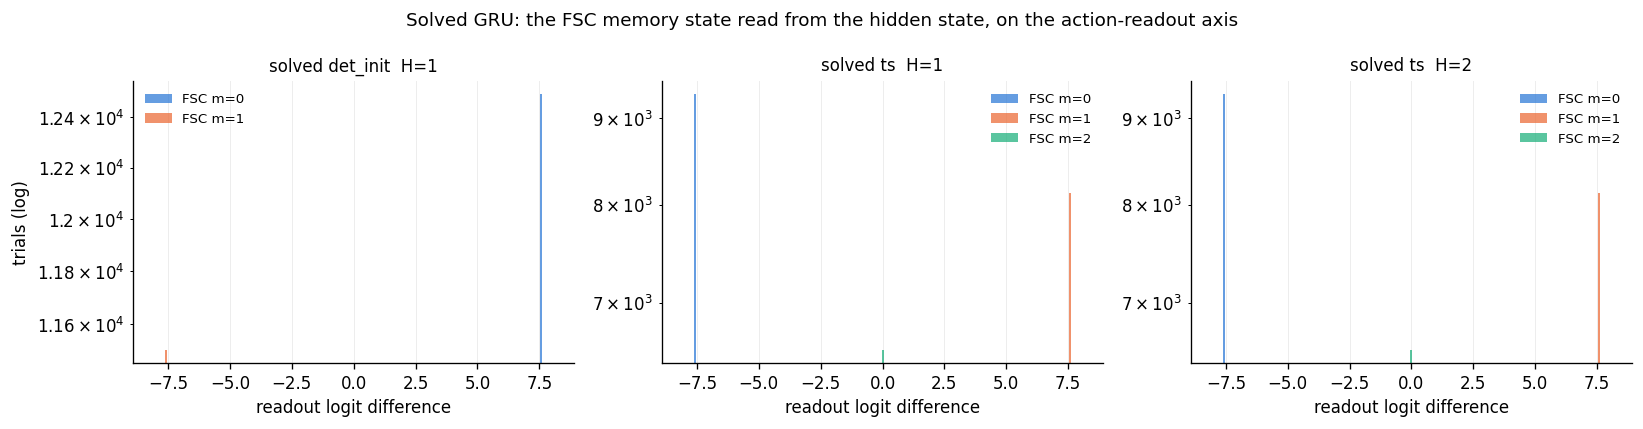

   dataset   H   state recovered on axis


  det_init   1                100.0000%


        ts   1                100.0000%


        ts   2                100.0000%


In [12]:
# project each solved hidden state onto the readout logit difference, colour by the true FSC state
def logit_axis(d, P, sessions):
    w = P["lin_W"][0] - P["lin_W"][1]; b = P["lin_b"][0] - P["lin_b"][1]; out = []
    for s in sessions:
        for h in rnn_states(P, s["actions"], s["observations"], d["A"], d["Y"])[:-1]:
            out.append(float(w @ np.atleast_1d(h) + b))
    return np.array(out)

def fsc_labels(d, sessions):
    return np.concatenate([fsc_beliefs(d["TMat"], d["rho"], d["M"],
                           s["actions"], s["observations"])[:-1].argmax(1) for s in sessions])

PANELS = [("det_init", 1), ("ts", 1), ("ts", 2)]
fig, axes = plt.subplots(1, len(PANELS), figsize=(4.6 * len(PANELS), 3.6))
for ax, (name, H) in zip(axes, PANELS):
    d = DATA[name]; P, E, _ = SOL[name][H]; ss = d["SESS"][:120]
    v = logit_axis(d, P, ss); lab = fsc_labels(d, ss)
    bins = np.linspace(v.min() - 0.5, v.max() + 0.5, 200)
    for m in range(d["M"]):
        if (lab == m).any():
            ax.hist(v[lab == m], bins=bins, color=C_STATE[m], alpha=0.72, label=f"FSC m={m}")
    ax.set_yscale("log"); ax.set_title(f"solved {name}  H={H}", fontsize=10)
    ax.set_xlabel("readout logit difference"); ax.legend(fontsize=8)
axes[0].set_ylabel("trials (log)")
fig.suptitle("Solved GRU: the FSC memory state read from the hidden state, on the action-readout axis",
             fontsize=11)
plt.tight_layout(); plt.show()

print(f"{'dataset':>10}  {'H':>2}  {'state recovered on axis':>24}")
for name, H in PANELS:
    d = DATA[name]; P, E, _ = SOL[name][H]; ss = d["SESS"][:120]
    v = logit_axis(d, P, ss); lab = fsc_labels(d, ss)
    meds = np.array([np.median(v[lab == m]) if (lab == m).any() else np.inf for m in range(d["M"])])
    acc = (np.argmin(np.abs(v[:, None] - meds[None, :]), axis=1) == lab).mean()
    print(f"{name:>10}  {H:>2}  {acc:>23.4%}")

### 4.2 Invertibility of the embedding

Decoding on the readout axis above asks whether the state is recoverable at all. Invertibility asks
something stricter: is there an **affine** map A h + b that returns the FSC memory state from the
hidden vector, so the two state spaces are in exact correspondence. Solving A e_m + b = u_m for the
M embedded states needs the matrix [E^T | 1] to have rank M, which requires **H >= M - 1**. Below
M - 1 there is no such map, no matter how the weights are set.

In [13]:
# fit the affine inverse A h + b = one-hot(m) from the embedded states; report its rank and error
def affine_inverse_from_embedding(E):
    Hh, Mm = E.shape
    S = np.hstack([E.T, np.ones((Mm, 1))])
    Theta, *_ = np.linalg.lstsq(S, np.eye(Mm), rcond=None)
    rank = int(np.linalg.matrix_rank(S, tol=1e-9))
    exact = float(np.abs(S @ Theta - np.eye(Mm)).max())
    return rank, exact

print(f"{'dataset':>10}  {'H':>2}  {'M':>2}  {'needs H>=M-1':>12}  {'rank[E^T|1]':>11}  "
      f"{'invertible':>10}  {'recon err':>10}")
for name in DATA:
    d = DATA[name]; M = d["M"]
    for H in H_LIST:
        P, E, _ = SOL[name][H]
        rank, err = affine_inverse_from_embedding(E)
        print(f"{name:>10}  {H:>2}  {M:>2}  {str(H >= M-1):>12}  {rank:>11}  "
              f"{str(rank == M):>10}  {err:>10.2e}")

   dataset   H   M  needs H>=M-1  rank[E^T|1]  invertible   recon err
  det_init   1   2          True            2        True    2.22e-16
  det_init   2   2          True            2        True    4.44e-16
  det_init   3   2          True            2        True    2.22e-16
        ts   1   3         False            2       False    6.67e-01
        ts   2   3          True            3        True    3.33e-16
        ts   3   3          True            3        True    5.76e-16


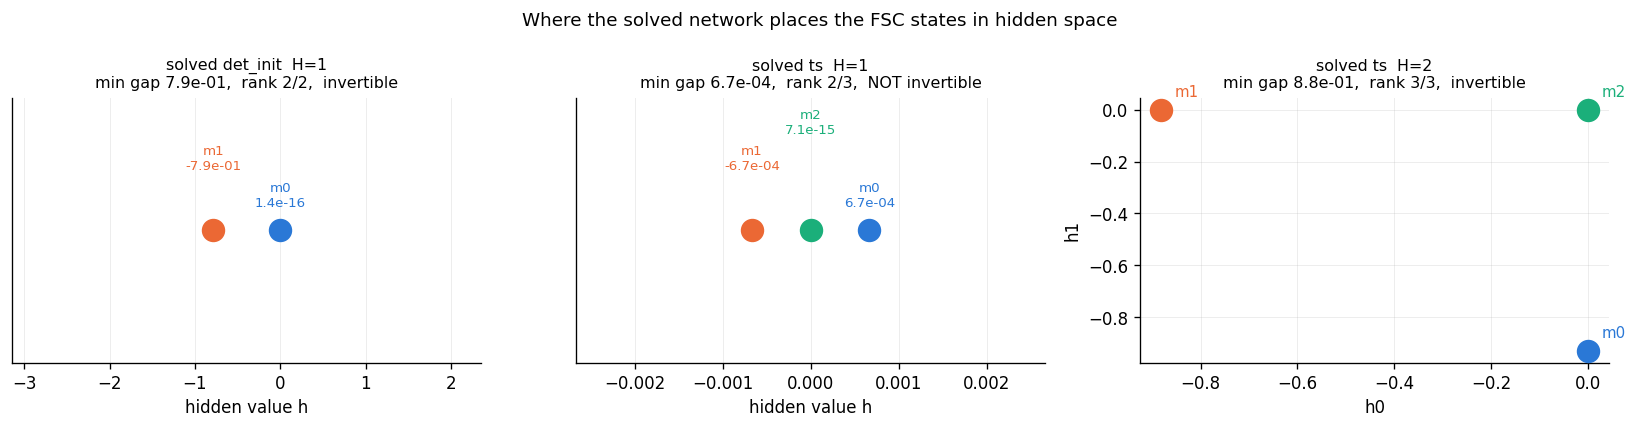

In [14]:
# the embedded states in hidden space: a line for H=1, a plane for H=2, with the min gap between states
fig, axes = plt.subplots(1, len(PANELS), figsize=(4.6 * len(PANELS), 3.6))
for ax, (name, H) in zip(axes, PANELS):
    d = DATA[name]; P, E, _ = SOL[name][H]; M = d["M"]
    rank, _ = affine_inverse_from_embedding(E)
    verdict = "invertible" if rank == M else "NOT invertible"
    if H == 1:
        for m in range(M):
            ax.scatter(E[0, m], 0.0, s=170, color=C_STATE[m], zorder=3)
            ax.annotate(f"m{m}\n{E[0,m]:.1e}", (E[0, m], 0.0), textcoords="offset points",
                        xytext=(0, 14 + 22 * m), ha="center", fontsize=8, color=C_STATE[m])
        gap = min(abs(E[0, i] - E[0, j]) for i in range(M) for j in range(i+1, M))
        pad = max(3 * gap, 1e-3)
        ax.set_xlim(E[0].min() - pad, E[0].max() + pad); ax.set_ylim(-1, 1)
        ax.set_yticks([]); ax.set_xlabel("hidden value h")
    else:
        for m in range(M):
            ax.scatter(E[0, m], E[1, m], s=170, color=C_STATE[m], zorder=3)
            ax.annotate(f"m{m}", (E[0, m], E[1, m]), textcoords="offset points",
                        xytext=(8, 8), fontsize=9, color=C_STATE[m])
        gap = min(np.linalg.norm(E[:, i] - E[:, j]) for i in range(M) for j in range(i+1, M))
        ax.set_xlabel("h0"); ax.set_ylabel("h1")
    ax.set_title(f"solved {name}  H={H}\nmin gap {gap:.1e},  rank {rank}/{M},  {verdict}", fontsize=9.5)
fig.suptitle("Where the solved network places the FSC states in hidden space", fontsize=11)
plt.tight_layout(); plt.show()

The three ts states at H = 1 sit within about 1e-3 of each other on a single line, and rank
[E^T | 1] is 2, one short of the M = 3 needed, so no affine map recovers the memory state: the
embedding is not invertible. The network still predicts correctly because the readout is a softmax,
which is nonlinear and can turn three points on a line into three different action distributions.
So a one-unit GRU reproduces the 3-state machine's behaviour while failing to hold its memory as a
recoverable state. At H = 2 the three states spread into the plane, rank is 3, and the map inverts.

## 5. Stability from the analytical initialization

Section 4 is about the solved network as it stands. This section starts from the solved weights and
trains (L1 = 0, no regularization), to ask whether the exact solution is a place training stays.
Two probes, sharing one harness: 5.1 varies the learning rate from the exact point; 5.2 knocks the
weights off the exact point by eps and asks whether training walks back. The metrics are the same
two as section 3.2, CE over data and track error, because the win-streak drift probe is saturated
at H = 1 and would read a dead network as a healthy one.

In [15]:
# torch bridge to and from the numpy weight dict, plus the batched data and the training harness
class TinyGRU(nn.Module):
    def __init__(self, Hd, A, Y):
        super().__init__(); self.rnn = nn.GRU(A + Y, Hd); self.lin = nn.Linear(Hd, A); self.Hd = Hd
    def forward(self, X):
        h0 = torch.zeros(1, X.shape[1], self.Hd, dtype=X.dtype)
        out, _ = self.rnn(X, h0); out = torch.cat((h0, out), 0); return self.lin(out)[:-1]

def to_torch(P, A, Y):
    m = TinyGRU(P["H"], A, Y); sd = m.state_dict()
    sd["rnn.weight_ih_l0"] = torch.tensor(P["W_ih"]); sd["rnn.weight_hh_l0"] = torch.tensor(P["W_hh"])
    sd["rnn.bias_ih_l0"] = torch.tensor(P["b_ih"]);  sd["rnn.bias_hh_l0"] = torch.tensor(P["b_hh"])
    sd["lin.weight"] = torch.tensor(P["lin_W"]);     sd["lin.bias"] = torch.tensor(P["lin_b"])
    m.load_state_dict(sd); return m

def from_torch(m):
    p = {k: v.detach().numpy() for k, v in m.rnn.named_parameters()}
    return {"W_ih": p["weight_ih_l0"], "W_hh": p["weight_hh_l0"],
            "b_ih": p["bias_ih_l0"], "b_hh": p["bias_hh_l0"],
            "lin_W": m.lin.weight.detach().numpy(), "lin_b": m.lin.bias.detach().numpy(), "H": m.Hd}

def batch(d, n):
    A, Y = d["A"], d["Y"]; S = d["SESS"][:n]; T = len(S[0]["actions"])
    X = np.zeros((T, len(S), A + Y)); Yt = np.zeros((T, len(S)), dtype=np.int64)
    for j, s in enumerate(S):
        for t in range(T):
            X[t, j, s["actions"][t]] = 1.0; X[t, j, A + s["observations"][t]] = 1.0
            Yt[t, j] = s["actions"][t]
    return torch.tensor(X), torch.tensor(Yt)

# train from P0; at each snapshot record CE over data and track error against the fixed embedding E
def train_track(d, P0, E, lr, epochs, every, n_train, eval_sess):
    A, Y = d["A"], d["Y"]; X, Yt = batch(d, n_train); m = to_torch(P0, A, Y)
    opt = torch.optim.AdamW(m.parameters(), lr=lr, weight_decay=0.0); lossf = nn.CrossEntropyLoss()
    ep, ce, tr = [], [], []
    for e in range(epochs + 1):
        if e % every == 0:
            Pn = from_torch(m)
            ep.append(e); ce.append(ce_rnn(d, Pn, eval_sess)); tr.append(track_error(d, Pn, E, eval_sess))
        opt.zero_grad(); loss = lossf(m(X).reshape(-1, A), Yt.reshape(-1)); loss.backward(); opt.step()
    return np.array(ep), np.array(ce), np.array(tr)

def flat(P): return np.concatenate([np.asarray(v).ravel() for k, v in P.items() if k != "H"])
def perturb(P, eps, seed):
    rng = np.random.default_rng(seed)
    return {k: (v if k == "H" else v + eps * rng.standard_normal(np.asarray(v).shape))
            for k, v in P.items()}

### 5.1 Learning-rate sweep from the exact point

In [16]:
# from the exact H=1 solve, sweep the learning rate; record CE and track error vs epoch, then cache
LR_LIST = [0.005, 0.001, 5e-4, 1e-4]
LR_H, EPOCHS, EVERY, TRAIN_N, EVAL_S = 1, 1500, 150, 200, 60
_eval = {name: DATA[name]["SESS"][:EVAL_S] for name in DATA}

LR_CACHE = os.path.join(REPO, "fitted_models", "_lrtest_cache.pkl")
LR_SIG = dict(lrs=LR_LIST, H=LR_H, epochs=EPOCHS, every=EVERY, n=TRAIN_N, evals=EVAL_S, names=list(DATA))
LRRUN = None
if os.path.exists(LR_CACHE):
    with open(LR_CACHE, "rb") as f: blob = pickle.load(f)
    if blob.get("sig") == LR_SIG: LRRUN = blob["runs"]
if LRRUN is None:
    LRRUN = {}
    for name in DATA:
        d = DATA[name]; P0, E, _ = SOL[name][LR_H]
        LRRUN[name] = {lr: train_track(d, P0, E, lr, EPOCHS, EVERY, TRAIN_N, _eval[name]) for lr in LR_LIST}
    with open(LR_CACHE, "wb") as f: pickle.dump(dict(sig=LR_SIG, runs=LRRUN), f)
print("done")

done


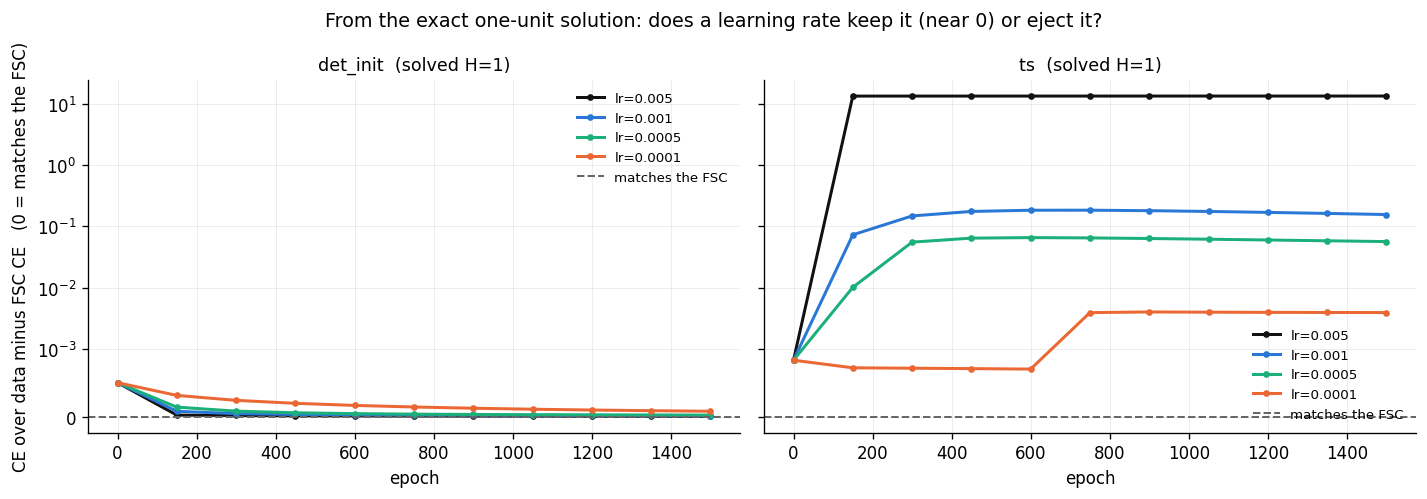

   dataset   H       lr   CE - FSC CE @0   CE - FSC CE @end
  det_init   1    0.005           0.0005             0.0000
  det_init   1    0.001           0.0005             0.0000
  det_init   1   0.0005           0.0005             0.0000
  det_init   1   0.0001           0.0005             0.0001
        ts   1    0.005           0.0008            13.5697
        ts   1    0.001           0.0008             0.1564
        ts   1   0.0005           0.0008             0.0565
        ts   1   0.0001           0.0008             0.0039


In [17]:
# cross-entropy minus the FSC's own CE, so 0 = matches the controller; symlog shows the 0 baseline
fig, axes = plt.subplots(1, len(DATA), figsize=(6.0 * len(DATA), 4.2), squeeze=False, sharey=True)
for col, name in enumerate(DATA):
    d = DATA[name]
    for i, lr in enumerate(LR_LIST):
        ep, ce, tr = LRRUN[name][lr]
        axes[0, col].plot(ep, ce - d["ce_fsc"], color=C_LR[i], lw=1.8, marker="o", ms=3, label=f"lr={lr:g}")
    axes[0, col].axhline(0.0, color="0.4", ls="--", lw=1.2, label="matches the FSC")
    axes[0, col].set_yscale("symlog", linthresh=1e-3)
    axes[0, col].set_title(f"{name}  (solved H={LR_H})", fontsize=10.5)
    axes[0, col].set_xlabel("epoch"); axes[0, col].legend(fontsize=8, loc="best")
axes[0, 0].set_ylabel("CE over data minus FSC CE   (0 = matches the FSC)")
fig.suptitle("From the exact one-unit solution: does a learning rate keep it (near 0) or eject it?", fontsize=11.5)
plt.tight_layout(); plt.show()

print(f"{'dataset':>10}  {'H':>2}  {'lr':>7}  {'CE - FSC CE @0':>15}  {'CE - FSC CE @end':>17}")
for name in DATA:
    d = DATA[name]
    for lr in LR_LIST:
        ep, ce, tr = LRRUN[name][lr]
        print(f"{name:>10}  {LR_H:>2}  {lr:>7g}  {ce[0]-d['ce_fsc']:>15.4f}  {ce[-1]-d['ce_fsc']:>17.4f}")

The curve is cross-entropy minus the FSC's own cross-entropy, so 0 means the network matches the
controller and any rise is the learning rate ejecting it. One learning rate reads the same on both
datasets: low rates hold near 0, a high rate on ts throws the one-unit solution off and its cross-entropy
explodes. Only cross-entropy is shown, because no second metric is trustworthy here. Track error, the
win-streak probe, the weight distance from the solution, and the best-fit belief residual were all tried,
and each fails the same way: on det_init they rise while behaviour stays perfect (the network keeps the
policy but slides its representation to an equivalent spot), and on ts they stay flat while behaviour is
destroyed (the one-unit weights are saturated, so the hidden state barely moves and the damage is entirely
in the readout). Only cross-entropy, which reads behaviour on the data, catches both facts.

### 5.2 Perturbation ladder: knock the weights off, then retrain

Run on `det_init` (the 2-state case, matching the original one-unit notebook). Take the solved
weights, add eps * xi with xi ~ N(0, I), retrain at L1 = 0, and ask whether the optimiser returns
to a network that reproduces the FSC. The control is the same optimiser and budget started from a
random init, the way an ordinary fit begins. `ts` at H = 1 is not run here: its solved weights reach
about 5689, a saturated needle in weight space, so any retraining either cannot move it or ejects it
outright (5.1 shows that ejection at lr = 0.005), and a perturbation of a fixed size is negligible
against weights that large.

In [18]:
# det_init: theta0 = theta* + eps*xi, retrain, verdict by CE over data; random-init is the control
PB_NAME = "det_init"
PLR, P_EPOCHS, P_SEEDS = 5e-4, 1200, [0, 1, 2]
EPS_LADDER, N_RANDOM = [0.0, 0.5, 1.0, 2.0, 4.0], 3
HOLD_CE = DATA[PB_NAME]["ce_fsc"] + 0.05

PB_CACHE = os.path.join(REPO, "fitted_models", "_perturb_cache.pkl")
PB_SIG = dict(name=PB_NAME, lr=PLR, epochs=P_EPOCHS, seeds=P_SEEDS, eps=EPS_LADDER, nrand=N_RANDOM,
              n=TRAIN_N, evals=EVAL_S, H=LR_H)
PBRUN = None
if os.path.exists(PB_CACHE):
    with open(PB_CACHE, "rb") as f: blob = pickle.load(f)
    if blob.get("sig") == PB_SIG: PBRUN = blob["runs"]
if PBRUN is None:
    d = DATA[PB_NAME]; Pstar, E, _ = SOL[PB_NAME][LR_H]; th0 = flat(Pstar); nrm = np.linalg.norm(th0)
    PBRUN = []
    for eps in EPS_LADDER:
        for sd in (P_SEEDS if eps > 0 else [0]):
            P0 = Pstar if eps == 0 else perturb(Pstar, eps, sd)
            _, ce, tr = train_track(d, P0, E, PLR, P_EPOCHS, P_EPOCHS, TRAIN_N, _eval[PB_NAME])
            PBRUN.append(dict(kind="solved", eps=eps, seed=sd,
                              rel=float(np.linalg.norm(flat(P0) - th0) / nrm),
                              ce_end=float(ce[-1]), tr_end=float(tr[-1])))
    for sd in range(N_RANDOM):
        torch.manual_seed(1000 + sd); Pr = from_torch(TinyGRU(LR_H, d["A"], d["Y"]).double())
        _, ce, tr = train_track(d, Pr, E, PLR, P_EPOCHS, P_EPOCHS, TRAIN_N, _eval[PB_NAME])
        PBRUN.append(dict(kind="random", eps=float("nan"), seed=sd,
                          rel=float(np.linalg.norm(flat(Pr) - th0) / nrm),
                          ce_end=float(ce[-1]), tr_end=float(tr[-1])))
    with open(PB_CACHE, "wb") as f: pickle.dump(dict(sig=PB_SIG, runs=PBRUN), f)
print("done")

done


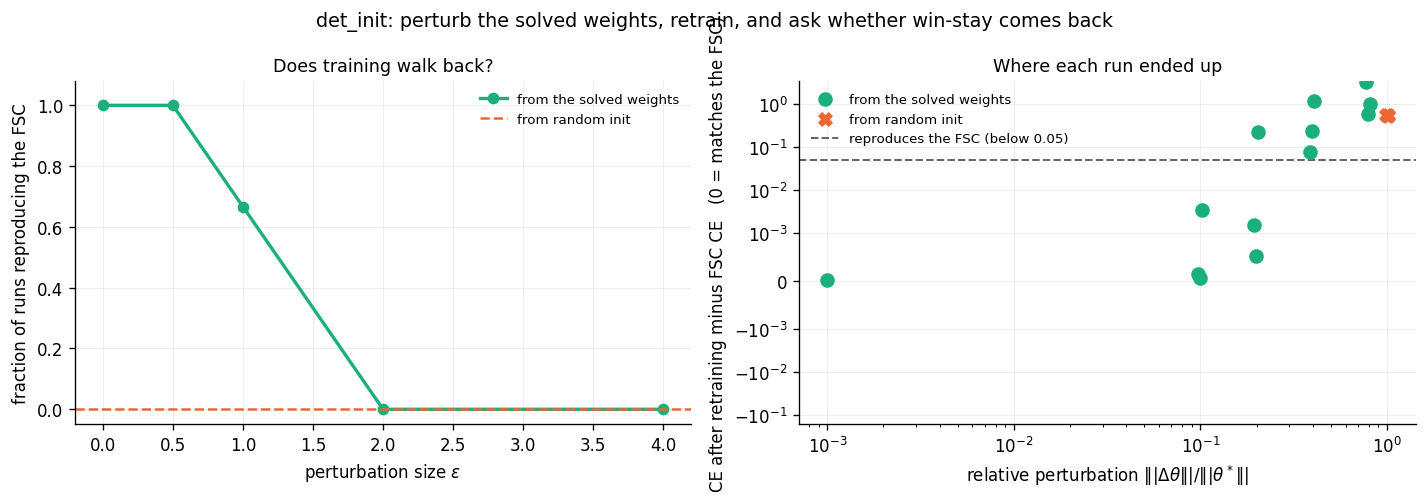

   start    eps  seed  rel dtheta    CE@end   track@end   verdict
  solved      0     0       0.000    0.0000    2.17e-01     holds
  solved    0.5     0       0.102    0.0036    1.08e-01     holds
  solved    0.5     1       0.097    0.0001    1.19e-01     holds
  solved    0.5     2       0.099    0.0001    1.38e-01     holds
  solved      1     0       0.203    0.2276    3.17e-01    broken
  solved      1     1       0.194    0.0016    1.33e-01     holds
  solved      1     2       0.199    0.0005    4.17e-01     holds
  solved      2     0       0.407    1.1720    3.83e-01    broken
  solved      2     1       0.388    0.0767    3.92e-01    broken
  solved      2     2       0.398    0.2371    5.67e-01    broken
  solved      4     0       0.813    1.0056    3.75e-01    broken
  solved      4     1       0.777    3.3393    5.64e-01    broken
  solved      4     2       0.795    0.6036    5.63e-01    broken
  random   rand     0       1.013    0.5350    7.87e-01    broken
  random  

In [19]:
# left: fraction of runs reproducing the FSC vs eps; right: CE@end vs relative perturbation
d = DATA[PB_NAME]; floor = d["ce_fsc"]
sol = [r for r in PBRUN if r["kind"] == "solved"]; ran = [r for r in PBRUN if r["kind"] == "random"]
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.2))

ax = axes[0]
fr = [(e, np.mean([r["ce_end"] <= HOLD_CE for r in sol if r["eps"] == e])) for e in EPS_LADDER]
ax.plot([e for e, _ in fr], [f for _, f in fr], "o-", color="#1baf7a", lw=2.0, ms=6,
        label="from the solved weights")
ax.axhline(np.mean([r["ce_end"] <= HOLD_CE for r in ran]), color="#eb6834", ls="--", lw=1.5,
           label="from random init")
ax.set_xlabel(r"perturbation size $\varepsilon$"); ax.set_ylim(-0.05, 1.08)
ax.set_ylabel("fraction of runs reproducing the FSC"); ax.set_title("Does training walk back?", fontsize=10.5)
ax.legend(fontsize=8, loc="best")

ax = axes[1]
ax.scatter([max(r["rel"], 1e-3) for r in sol], [r["ce_end"] - floor for r in sol], s=60,
           color="#1baf7a", zorder=3, label="from the solved weights")
ax.scatter([max(r["rel"], 1e-3) for r in ran], [r["ce_end"] - floor for r in ran], s=60, marker="X",
           color="#eb6834", zorder=3, label="from random init")
ax.axhline(HOLD_CE - floor, color="0.4", ls="--", lw=1.2,
           label=f"reproduces the FSC (below {HOLD_CE - floor:.2f})")
ax.set_xscale("log"); ax.set_yscale("symlog", linthresh=1e-3)
ax.set_xlabel(r"relative perturbation $\||\Delta\theta\||/\||\theta^*\||$")
ax.set_ylabel("CE after retraining minus FSC CE   (0 = matches the FSC)"); ax.set_title("Where each run ended up", fontsize=10.5)
ax.legend(fontsize=8, loc="best")
fig.suptitle(f"{PB_NAME}: perturb the solved weights, retrain, and ask whether win-stay comes back",
             fontsize=11.5)
plt.tight_layout(); plt.show()

print(f"{'start':>8}  {'eps':>5}  {'seed':>4}  {'rel dtheta':>10}  {'CE@end':>8}  "
      f"{'track@end':>10}  {'verdict':>8}")
for r in PBRUN:
    eps = "rand" if r["kind"] == "random" else f"{r['eps']:g}"
    ok = "holds" if r["ce_end"] <= HOLD_CE else "broken"
    print(f"{r['kind']:>8}  {eps:>5}  {r['seed']:>4}  {r['rel']:>10.3f}  {r['ce_end']:>8.4f}  "
          f"{r['tr_end']:>10.2e}  {ok:>8}")